# ARDPP user study, analysis

Reads `ARDPP_study_data.xlsx` and derives every reported value from it. Nothing in this notebook is
hard-coded: the tables, the statistics and the two figures are all computed from the raw sheets, so
re-running it after a data correction reproduces the whole analysis.

**Run order:** top to bottom. Cell 2 refuses to continue if the data fails its integrity checks.

**Outputs written next to the notebook:** `ARDPP_study_results.xlsx`,
`fig_completion_times.png/.svg`, `fig_usability_scores.png/.svg`.

In [1]:
# --- setup and load -----------------------------------------------------------
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

SRC = Path("ARDPP_study_data.xlsx")
assert SRC.exists(), f"{SRC} not found. Put it next to this notebook."

sheets = pd.read_excel(SRC, sheet_name=None)

def rows_of(name, key, pattern):
    """Return only the real data rows of a sheet, dropping any trailing note lines."""
    df = sheets[name]
    df = df[df[key].astype(str).str.fullmatch(pattern, na=False)].copy()
    return df.reset_index(drop=True)

participants = rows_of("participants",          "participant", r"P\d+")
times        = rows_of("completion_times",      "participant", r"P\d+")
reports      = rows_of("session_reports",       "participant", r"P\d+")
u_items      = rows_of("usability_items",       "participant", r"P\d+")
u_text       = rows_of("usability_item_text",   "item",        r"q\d+")
c_items      = rows_of("comparative_items",     "participant", r"P\d+")
c_text       = rows_of("comparative_item_text", "item",        r"c\d+")
open_answers = rows_of("open_answers",          "participant", r"P\d+")
exp_scale    = sheets["experience_scale"].dropna(subset=["value"])
exp_scale    = exp_scale[pd.to_numeric(exp_scale["value"], errors="coerce").notna()]
# a blank label means the form carried no wording for that scale point
EXP_LABEL    = {int(v): (None if pd.isna(l) else str(l))
                for v, l in zip(exp_scale["value"], exp_scale["label"])}

STEP_COLS = [f"step_{i}_s" for i in range(1, 6)]
Q_COLS    = [f"q{i}" for i in range(1, 11)]
C_COLS    = [f"c{i}" for i in range(1, 11)]
BLUE, AMBER, GREY = "#0072B2", "#E69F00", "#9A9A9A"

# response scales, confirmed by the author 2026-08-25 and recorded in the workbook
COMP_LOW, COMP_HIGH = "the two-dimensional manual", "the Augmented Reality model"
COND_NAME = {"manual": "two-dimensional manual", "ar": "Augmented Reality"}
USAB_LOW, USAB_HIGH = "disagree", "agree"

print(f"participants {len(participants)} · timed runs {len(times)} · "
      f"questionnaire rows {len(u_items)} · open answers {len(open_answers)}")

participants 9 · timed runs 17 · questionnaire rows 18 · open answers 54


In [2]:
# --- integrity checks. This cell stops the analysis rather than reporting a wrong number.
P = sorted(participants["participant"])
assert len(P) == len(set(P)), "duplicate participant identifiers"
assert set(times["participant"]) <= set(P), "a timed run names an unknown participant"
assert set(u_items["participant"]) == set(P), "questionnaire and participant lists disagree"
assert set(times["condition"]) == {"manual", "ar"}, "unexpected condition label"
assert set(participants["first_condition"]) <= {"manual", "ar"}, "unexpected first_condition label"
assert participants["first_condition"].notna().all(), "a participant has no condition order recorded"

for col in Q_COLS:
    bad = u_items.loc[~u_items[col].between(1, 5), "participant"].tolist()
    assert not bad, f"{col} out of the 1 to 5 range for {bad}"
for col in C_COLS:
    bad = c_items.loc[~c_items[col].between(1, 5), "participant"].tolist()
    assert not bad, f"{col} out of the 1 to 5 range for {bad}"

assert set(u_text["polarity"]) <= {"positive", "negative"}, "unknown polarity value"
assert len(u_text) == 10 and len(c_text) == 10, "expected ten items per instrument"

# every participant should hold exactly one questionnaire row per condition
counts = u_items.groupby(["participant", "condition"]).size()
assert counts.eq(1).all(), "a participant has more than one questionnaire row for a condition"

# the application's own elapsed value against the sum of its per-step values
ar = times[times["condition"] == "ar"].copy()
ar["step_sum_s"] = ar[STEP_COLS].sum(axis=1)
ar["reporting_gap_s"] = ar["app_elapsed_s"] - ar["step_sum_s"]
gap = ar.loc[ar["reporting_gap_s"] != 0, ["participant", "app_elapsed_s", "step_sum_s", "reporting_gap_s"]]
print(f"runs where the reported elapsed value differs from the sum of its steps: {len(gap)} of {len(ar)}")
if len(gap):
    print(gap.to_string(index=False))
    print(f"largest difference: {gap['reporting_gap_s'].abs().max():.0f} s")
print("\nall integrity checks passed")

runs where the reported elapsed value differs from the sum of its steps: 5 of 9
participant  app_elapsed_s  step_sum_s  reporting_gap_s
        P02          458.0       460.0             -2.0
        P03          325.0       324.0              1.0
        P05          314.0       316.0             -2.0
        P06          187.0       186.0              1.0
        P09          201.0       199.0              2.0
largest difference: 2 s

all integrity checks passed


## Participants

Three separate figures, one per background variable, so each can be placed and captioned on its own:
age group as a pie, prior experience with headsets as bars, prior experience disassembling electronic
devices as bars. The bar labels come from the `experience_scale` sheet, so correcting a label there
changes the chart. The two bar figures share one horizontal axis limit, so their bar lengths are
directly comparable across the two figures.

Profession is not charted: nine participants gave nine different professions, so a bar chart of them
is a list drawn as bars. It stays in the participants table.

In [3]:
# --- participants: shared setup for the three background figures ---------------
# Tick labels. If every scale point carries wording on the form, the words are used on their
# own. If the middle points carry none, the numbers stay and only the two confirmed endpoints
# are named, so no label is invented. The choice is made in the workbook, not here.
SCALE_POINTS = sorted(EXP_LABEL)
WORDS_ALL    = all(EXP_LABEL[v] for v in SCALE_POINTS)
LEVELS       = [EXP_LABEL[v] if WORDS_ALL
                else (f"{v}\n{EXP_LABEL[v]}" if EXP_LABEL[v] else str(v))
                for v in SCALE_POINTS]
PIE_COLORS = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9"]
GREEN      = "#009E73"
N          = len(participants)

age = participants["age_group"].value_counts().sort_index()

def exp_counts(col):
    """Counts per scale point, in scale order, zeros included."""
    s = participants[col].astype(int).value_counts()
    return [int(s.get(v, 0)) for v in SCALE_POINTS]

xr, ee = exp_counts("prior_xr_experience"), exp_counts("prior_disassembly_experience")

# one shared limit so the two experience figures can be compared bar for bar
XMAX = max(max(xr), max(ee)) + 1

def experience_figure(vals, colour, title, outfile):
    """One horizontal bar chart of a five-point experience scale."""
    fig, ax = plt.subplots(figsize=(8.0, 3.6))
    y = np.arange(len(LEVELS))
    ax.barh(y, vals, color=colour, height=0.62)
    ax.set_yticks(y); ax.set_yticklabels(LEVELS, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("participants")
    ax.set_xlim(0, XMAX)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.grid(axis="x", lw=0.5, alpha=0.35); ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    for yi, v in zip(y, vals):
        if v:
            ax.text(v + 0.12, yi, str(v), va="center", fontsize=10)
    ax.set_title(f"{title}, n = {N}", fontsize=12, fontweight="bold", pad=10)
    ends = ", ".join(f"{v} {EXP_LABEL[v]}" for v in SCALE_POINTS if EXP_LABEL[v])
    fig.text(0.5, -0.06,
             "Bar labels give the number of participants. Self-rated on a five-point scale, "
             + ("scale labels as worded on the form." if WORDS_ALL else f"where {ends}."),
             ha="center", fontsize=8.5, style="italic")
    fig.tight_layout()
    fig.savefig(outfile + ".png", dpi=300, bbox_inches="tight")
    fig.savefig(outfile + ".svg", bbox_inches="tight")
    return fig

print("age groups   ", dict(age))
print("headsets     ", dict(zip(SCALE_POINTS, xr)))
print("disassembly  ", dict(zip(SCALE_POINTS, ee)))
print("scale        ", "words on every point" if WORDS_ALL else
      "endpoints only: " + ", ".join(f"{v} = {EXP_LABEL[v]}"
                                     for v in SCALE_POINTS if EXP_LABEL[v]))

age groups    {'18–24': np.int64(2), '25–34': np.int64(4), '45+': np.int64(3)}
headsets      {1: 4, 2: 2, 3: 1, 4: 1, 5: 1}
disassembly   {1: 5, 2: 1, 3: 0, 4: 2, 5: 1}
scale         endpoints only: 1 = never used, 5 = expert


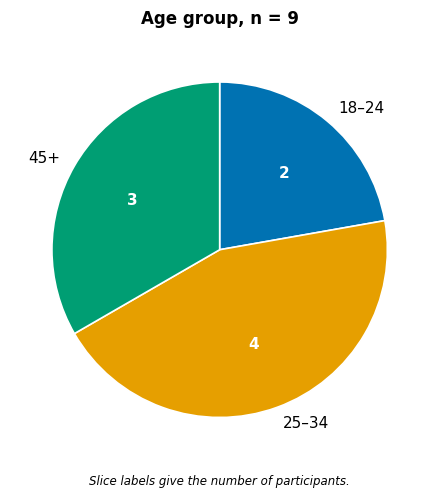

In [4]:
# --- figure 1 of 3: age group -------------------------------------------------
fig, ax = plt.subplots(figsize=(5.4, 4.8))
w, _, at = ax.pie(age.values, labels=age.index,
                  autopct=lambda p: f"{round(p * age.values.sum() / 100)}",
                  colors=PIE_COLORS[:len(age)], startangle=90, counterclock=False,
                  wedgeprops=dict(edgecolor="white", linewidth=1.2),
                  textprops=dict(fontsize=11))
for t in at:
    t.set_color("white"); t.set_fontweight("bold")
ax.set_title(f"Age group, n = {N}", fontsize=12, fontweight="bold", pad=12)
fig.text(0.5, -0.02, "Slice labels give the number of participants.",
         ha="center", fontsize=8.5, style="italic")
fig.tight_layout()
fig.savefig("fig_participants_age.png", dpi=300, bbox_inches="tight")
fig.savefig("fig_participants_age.svg", bbox_inches="tight")
plt.show()

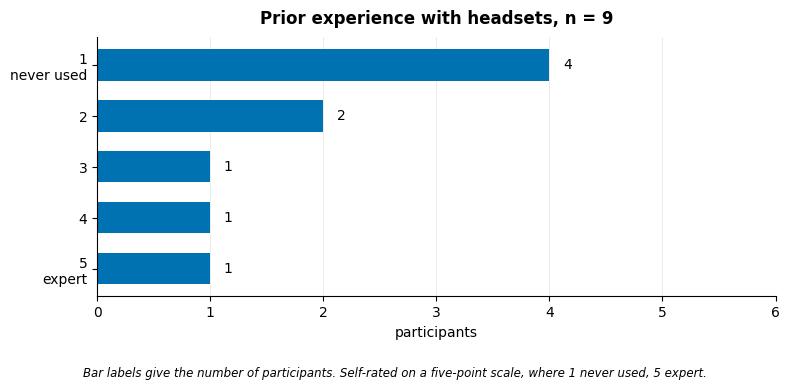

In [5]:
# --- figure 2 of 3: prior experience with headsets -----------------------------
experience_figure(xr, BLUE, "Prior experience with headsets",
                  "fig_participants_headset_experience")
plt.show()

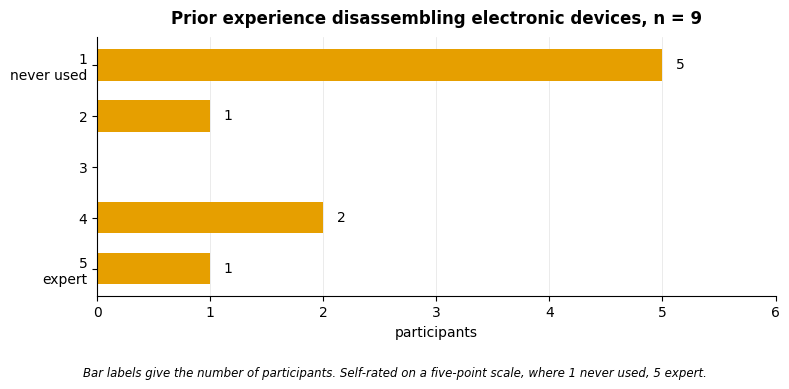

In [6]:
# --- figure 3 of 3: prior experience disassembling electronic devices ----------
experience_figure(ee, AMBER, "Prior experience disassembling electronic devices",
                  "fig_participants_disassembly_experience")
plt.show()

In [7]:
# --- the participants table ----------------------------------------------------
# Scale values are written out only where the form carried wording for that point.
demo = participants.copy()
demo["first_condition"] = demo["first_condition"].map(COND_NAME)
for col in ("prior_xr_experience", "prior_disassembly_experience"):
    demo[col] = demo[col].astype(int).map(
        lambda v: f"{v} ({EXP_LABEL[v]})" if EXP_LABEL.get(v) else str(v))
print(demo.to_string(index=False))
print(f"\nBoth experience columns are self-rated 1 to 5, where "
      + ", ".join(f"{v} is {EXP_LABEL[v]}" for v in SCALE_POINTS if EXP_LABEL[v]) + ".")

FIRST = dict(zip(participants["participant"], participants["first_condition"]))
oc = participants["first_condition"].value_counts()
print(f"\ncondition performed first, all nine: "
      + ", ".join(f"{COND_NAME[k]} {v}" for k, v in oc.items()))

participant age_group                    field prior_xr_experience prior_disassembly_experience        first_condition
        P01       45+       Innovation manager          5 (expert)               1 (never used)      Augmented Reality
        P02       45+              Electrician      1 (never used)                            4      Augmented Reality
        P03     25–34        Marketing Analyst                   3                            2      Augmented Reality
        P04     18–24         Strategic design      1 (never used)               1 (never used) two-dimensional manual
        P05     25–34 Marketing & Social Midia      1 (never used)               1 (never used) two-dimensional manual
        P06     18–24                  Student                   4                            4      Augmented Reality
        P07     25–34                Economist                   2               1 (never used) two-dimensional manual
        P08       45+                  Retired  

In [8]:
# --- completion time ----------------------------------------------------------
t = times.copy()
t["total_s"] = t[STEP_COLS].sum(axis=1)

wide = t.pivot(index="participant", columns="condition", values="total_s").rename(
    columns={"manual": "manual_s", "ar": "ar_s"})
wide["difference_s"] = wide["ar_s"] - wide["manual_s"]
wide = wide.reindex(sorted(wide.index))

paired = wide.dropna(subset=["manual_s"])
print("per participant")
print(wide.to_string(float_format=lambda v: f"{v:.0f}"))

summary_t = pd.DataFrame({
    "manual":            paired["manual_s"].agg(["mean","median","min","max","std"]),
    "augmented_reality": paired["ar_s"].agg(["mean","median","min","max","std"]),
    "difference":        paired["difference_s"].agg(["mean","median","min","max","std"])}).round(1)
print("\nsummary over the", len(paired), "participants who performed both conditions")
print(summary_t.to_string())
slower = int((paired["difference_s"] > 0).sum())
print(f"\nAugmented Reality slower for {slower} of {len(paired)}, faster for {len(paired)-slower}")
print(f"all {int(wide['ar_s'].notna().sum())} Augmented Reality runs: "
      f"mean {wide['ar_s'].mean():.1f} s, median {wide['ar_s'].median():.1f} s")
r_t = paired["manual_s"].corr(paired["ar_s"])
print(f"Pearson r between the two conditions, n = {len(paired)}: {r_t:.3f}")

# --- order of the two conditions ----------------------------------------------
# The order alternates between participants, so the sequence is set beside the result
# rather than left for a reader to ask about. Counts only; nothing is joined here.
ord_t = paired.copy()
ord_t["first_condition"] = [FIRST[p] for p in ord_t.index]
ord_t["first_s"]  = np.where(ord_t["first_condition"] == "ar",
                             ord_t["ar_s"], ord_t["manual_s"])
ord_t["second_s"] = np.where(ord_t["first_condition"] == "ar",
                             ord_t["manual_s"], ord_t["ar_s"])
ord_t["second_faster"] = ord_t["second_s"] < ord_t["first_s"]

oc = ord_t["first_condition"].value_counts()
print("\ncondition order, over the", len(ord_t), "who performed both")
print("  started with " + ", ".join(f"{COND_NAME[k]}: {v}" for k, v in oc.items()))
print(ord_t[["first_condition", "first_s", "second_s", "second_faster"]].to_string(
      float_format=lambda v: f"{v:.0f}"))

sf = int(ord_t["second_faster"].sum())
print(f"\n  shorter time in the second condition performed: {sf} of {len(ord_t)} "
      f"{sorted(ord_t.index[ord_t['second_faster']])}")
for k in ("ar", "manual"):
    g = ord_t[ord_t["first_condition"] == k]
    n_slow = int((g["difference_s"] > 0).sum())
    print(f"  of the {len(g)} who started with the {COND_NAME[k]} condition, the Augmented "
          f"Reality run was the slower of the two for {n_slow}")

per participant
condition    ar_s  manual_s  difference_s
participant                              
P01           418       NaN           NaN
P02           460       440            20
P03           324       299            25
P04           376       357            19
P05           316       301            15
P06           186       201           -15
P07           235       261           -26
P08           450       427            23
P09           199       214           -15

summary over the 8 participants who performed both conditions
        manual  augmented_reality  difference
mean     312.5              318.2         5.8
median   300.0              320.0        17.0
min      201.0              186.0       -26.0
max      440.0              460.0        25.0
std       89.8              106.5        20.7

Augmented Reality slower for 5 of 8, faster for 3
all 9 Augmented Reality runs: mean 329.3 s, median 324.0 s
Pearson r between the two conditions, n = 8: 0.992

condition order, over

In [9]:
# --- perceived usability, scored from the items using the polarity column ------
pol = u_text.set_index("item")["polarity"].to_dict()

def score_row(row):
    s = 0
    for q in Q_COLS:
        v = row[q]
        s += (v - 1) if pol[q] == "positive" else (5 - v)
    return s * 2.5

u = u_items.copy()
u["score"] = u.apply(score_row, axis=1)
assert u["score"].between(0, 100).all(), "a score fell outside 0 to 100"

usab = u.pivot(index="participant", columns="condition", values="score").rename(
    columns={"manual": "manual", "ar": "augmented_reality"})
usab["difference"] = usab["augmented_reality"] - usab["manual"]
usab = usab.reindex(sorted(usab.index))
print(usab.to_string(float_format=lambda v: f"{v:.1f}"))

summary_u = usab.agg(["mean","median","min","max"]).round(1)
print("\n", summary_u.to_string(), sep="")
higher = int((usab["difference"] > 0).sum())
print(f"\nAugmented Reality scored higher for {higher} of {len(usab)}")
print(f"mean difference {usab['difference'].mean():+.1f}, "
      f"median difference {usab['difference'].median():+.1f}")
print("The mean and the median differ because one participant's large negative difference pulls the mean.")

condition    augmented_reality  manual  difference
participant                                       
P01                      100.0    85.0        15.0
P02                       42.5    97.5       -55.0
P03                       80.0    92.5       -12.5
P04                       85.0    70.0        15.0
P05                       87.5    65.0        22.5
P06                       97.5    92.5         5.0
P07                       97.5    85.0        12.5
P08                       65.0    32.5        32.5
P09                      100.0    95.0         5.0

condition  augmented_reality  manual  difference
mean                    83.9    79.4         4.4
median                  87.5    85.0        12.5
min                     42.5    32.5       -55.0
max                    100.0    97.5        32.5

Augmented Reality scored higher for 7 of 9
mean difference +4.4, median difference +12.5
The mean and the median differ because one participant's large negative difference pulls the mean.


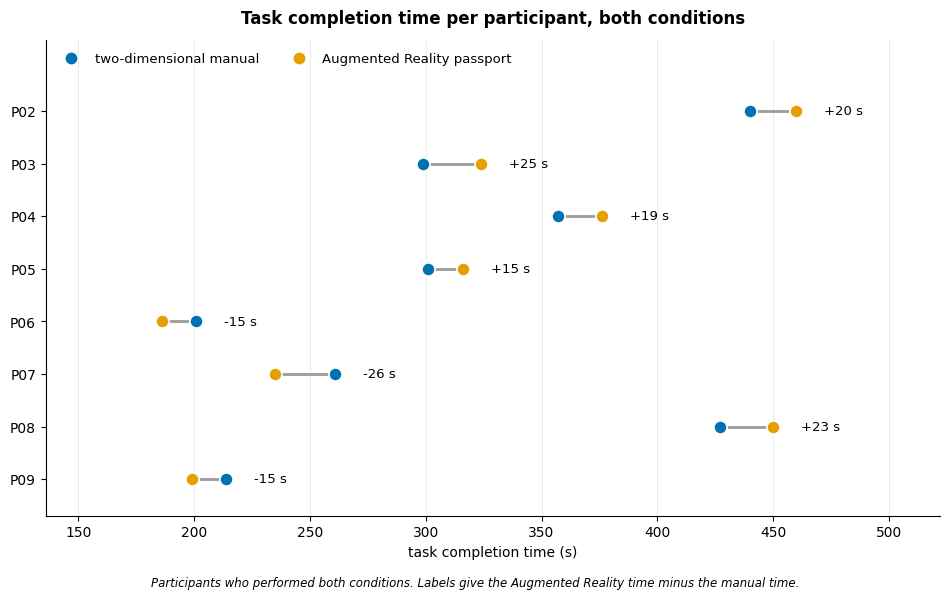

In [10]:
# --- the two figures. One function, so both read the same way -----------------
def dumbbell(frame, left, right, label_fmt, xlabel, title, note, xlim, pad, outfile):
    order = list(frame.index)
    fig, ax = plt.subplots(figsize=(9.6, 5.8))
    y = np.arange(len(order))[::-1]
    for yi, p in zip(y, order):
        a, b = frame.loc[p, left], frame.loc[p, right]
        if pd.isna(a) or pd.isna(b):
            continue
        ax.plot([a, b], [yi, yi], color=GREY, lw=2, zorder=1, solid_capstyle="round")
        ax.scatter([a], [yi], s=90, color=BLUE,  zorder=3, edgecolor="white", lw=1.2)
        ax.scatter([b], [yi], s=90, color=AMBER, zorder=3, edgecolor="white", lw=1.2)
        ax.text(max(a, b) + pad, yi, label_fmt.format(b - a), va="center", fontsize=9.5)
    ax.set_yticks(y); ax.set_yticklabels(order, fontsize=10)
    ax.set_xlabel(xlabel); ax.set_xlim(*xlim); ax.set_ylim(-0.7, len(order) + 0.35)
    ax.grid(axis="x", lw=0.5, alpha=0.35); ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.scatter([], [], s=90, color=BLUE,  label="two-dimensional manual",    edgecolor="white")
    ax.scatter([], [], s=90, color=AMBER, label="Augmented Reality passport", edgecolor="white")
    ax.legend(loc="upper left", frameon=False, fontsize=9.5, ncol=2, bbox_to_anchor=(0.0, 1.0))
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
    fig.text(0.5, -0.02, note, ha="center", fontsize=8.5, style="italic")
    fig.tight_layout()
    fig.savefig(outfile + ".png", dpi=300, bbox_inches="tight")
    fig.savefig(outfile + ".svg", bbox_inches="tight")
    return fig

lo, hi = paired[["manual_s", "ar_s"]].min().min(), paired[["manual_s", "ar_s"]].max().max()
dumbbell(paired, "manual_s", "ar_s", "{:+.0f} s",
         "task completion time (s)",
         "Task completion time per participant, both conditions",
         "Participants who performed both conditions. "
         "Labels give the Augmented Reality time minus the manual time.",
         (lo - 50, hi + 62), 12, "fig_completion_times")
plt.show()

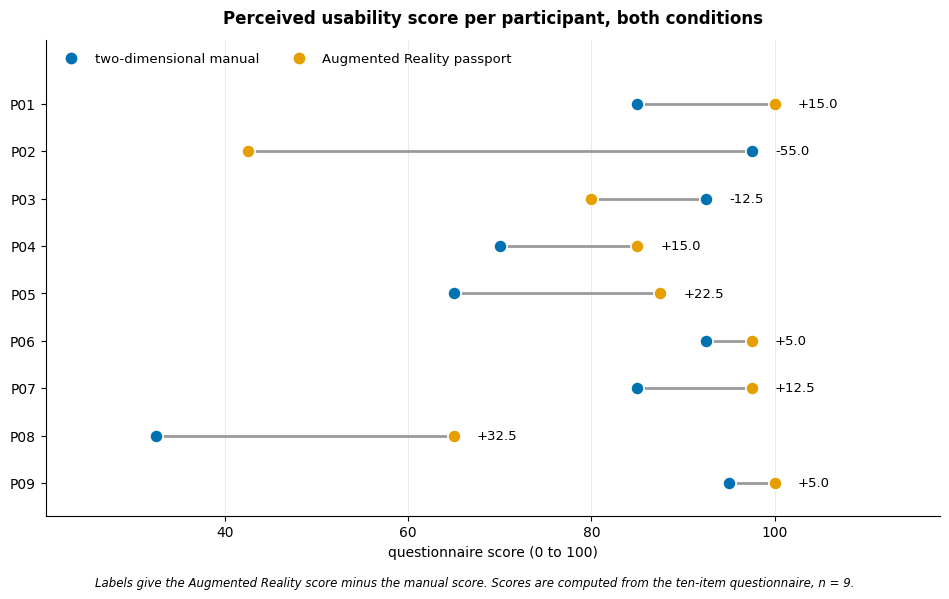

In [11]:
ulo, uhi = usab[["manual", "augmented_reality"]].min().min(), usab[["manual", "augmented_reality"]].max().max()
dumbbell(usab, "manual", "augmented_reality", "{:+.1f}",
         "questionnaire score (0 to 100)",
         "Perceived usability score per participant, both conditions",
         f"Labels give the Augmented Reality score minus the manual score. "
         f"Scores are computed from the ten-item questionnaire, n = {len(usab)}.",
         (ulo - 12, uhi + 18), 2.5, "fig_usability_scores")
plt.show()

In [12]:
# --- comparative items --------------------------------------------------------
# Answered 1 to 5, where 1 is the two-dimensional manual and 5 is the Augmented Reality model.
# Tabulated, not plotted: with nine responses a bar chart draws a distribution that is not there.
comp = c_items.set_index("participant")[C_COLS].reindex(sorted(c_items["participant"])).astype(float)

tab = comp.T
tab.insert(0, "wording", c_text.set_index("item")["wording"])
tab["median"]  = comp.median().values
tab["mean"]    = comp.mean().round(2).values
# three bands, so nothing is claimed about what the midpoint meant to the participant
tab["toward_ar"]      = (comp >= 4).sum().values
tab["midpoint"]       = (comp == 3).sum().values
tab["toward_manual"]  = (comp <= 2).sum().values

print(f"1 = {COMP_LOW}   ·   5 = {COMP_HIGH}   ·   n = {len(comp)}\n")
print(tab.to_string())

unanimous = [i for i in C_COLS if comp[i].nunique() == 1]
print(f"\nitems answered identically by every participant: {unanimous or 'none'}")

allfive = list(comp.index[(comp == 5).all(axis=1)])
cells   = comp.size
print(f"participants who answered 5 on all ten items: {len(allfive)} of {len(comp)} {allfive}")
print(f"responses at 5: {int((comp == 5).sum().sum())} of {cells} cells "
      f"({(comp == 5).sum().sum() / cells:.1%})")
print(f"every item returns a median of 5: {bool((comp.median() == 5).all())}")

# c1 asks which version let the participant work with more agility. The timed runs give an
# independent measure of the same thing, so the two are set side by side. Counts only.
slower = set(wide.index[wide["difference_s"] > 0])
c1_ar  = set(comp.index[comp["c1"] >= 4])
c1_man = set(comp.index[comp["c1"] <= 2])
both   = set(wide.dropna(subset=["manual_s"]).index)
print(f"\nagility item against the measured times, over the {len(both)} who performed both:")
print(f"  slower with the Augmented Reality condition: {len(slower & both)} "
      f"{sorted(slower & both)}")
print(f"  of those, answered the agility item toward the Augmented Reality model: "
      f"{len(slower & c1_ar & both)} {sorted(slower & c1_ar & both)}")
print(f"  of those, answered it toward the manual: {len(slower & c1_man & both)} "
      f"{sorted(slower & c1_man & both)}")

1 = the two-dimensional manual   ·   5 = the Augmented Reality model   ·   n = 9

participant                                                                                                     wording  P01  P02  P03  P04  P05  P06  P07  P08  P09  median  mean  toward_ar  midpoint  toward_manual
c1                                            Which version let you work with more agility (faster, smoother progress)?  5.0  1.0  5.0  5.0  1.0  5.0  5.0  5.0  5.0     5.0  4.11          7         0              2
c2                                                            Which version made the instructions easier to understand?  5.0  3.0  5.0  5.0  5.0  5.0  5.0  5.0  5.0     5.0  4.78          8         1              0
c3                                         Which version made it easier to identify the correct component at each step?  5.0  3.0  5.0  5.0  5.0  5.0  5.0  5.0  5.0     5.0  4.78          8         1              0
c4                                       Which version gav

### The comparative items as a figure

Every one of the 90 responses is drawn, one cell per participant per item, coloured by the value
recorded. Nothing is averaged and nothing is aggregated, so the figure carries exactly what the table
carries and cannot imply a distribution the nine responses do not support. The colour runs from the
two-dimensional manual at 1 to the Augmented Reality model at 5, with the midpoint left unnamed
because the form does not record its wording. The right-hand column gives, per item, how many of the
nine answered 4 or 5.

Row labels come from the `short_label` column of the `comparative_item_text` sheet. The full item
wording stays in the table and in the appendix.

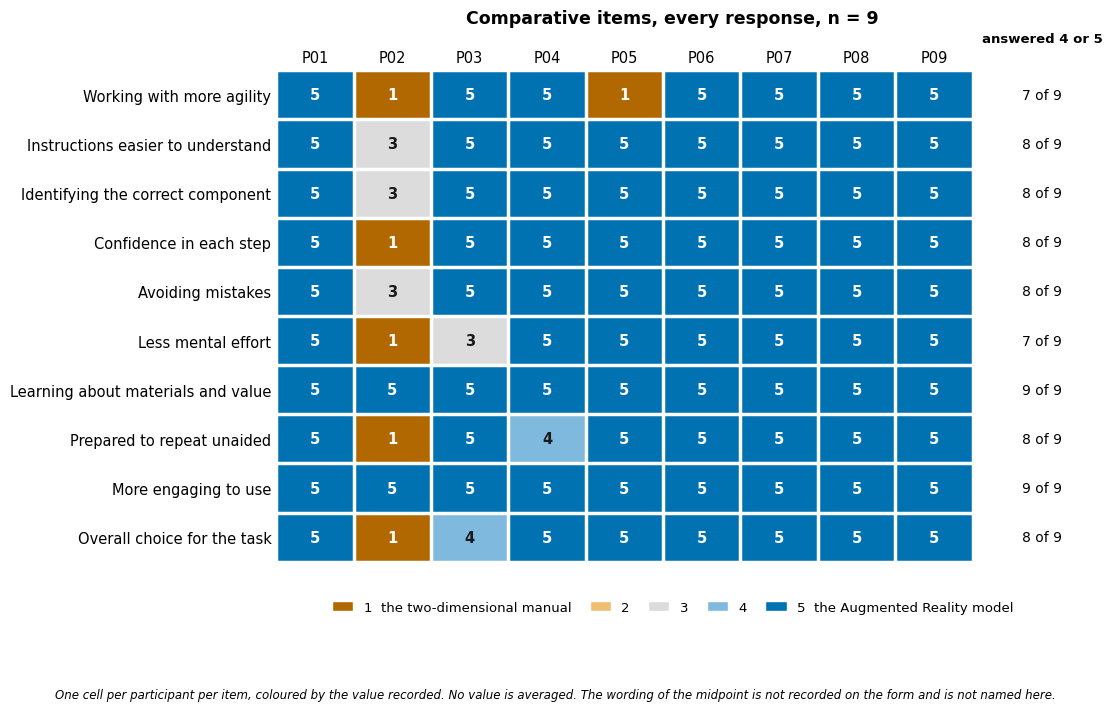

cells drawn: 90  ·  values present: {1: 6, 3: 4, 4: 2, 5: 78}


In [13]:
# --- comparative items, response matrix ---------------------------------------
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

SHORT = c_text.set_index("item")["short_label"].to_dict()
VALUE_COLOR = {1: "#B26800", 2: "#F0BE70", 3: "#DCDCDC", 4: "#7FB9DE", 5: "#0072B2"}
LIGHT_TEXT  = {1, 5}

mat   = comp[C_COLS].T                      # rows are items, columns are participants
order = list(mat.index)
cols  = list(mat.columns)

cmap = ListedColormap([VALUE_COLOR[v] for v in range(1, 6)])
norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5, 5.5], cmap.N)

fig, ax = plt.subplots(figsize=(11.2, 6.4))
ax.imshow(mat.values, cmap=cmap, norm=norm, aspect="auto")

for i, item in enumerate(order):
    for j, p in enumerate(cols):
        v = int(mat.loc[item, p])
        ax.text(j, i, str(v), ha="center", va="center", fontsize=10.5, fontweight="bold",
                color="white" if v in LIGHT_TEXT else "#1A1A1A")

# white separators, drawn as minor gridlines so no cell border is lost at the edges
ax.set_xticks(np.arange(-0.5, len(cols), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(order), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2.5)
ax.tick_params(which="minor", length=0)

ax.set_xticks(range(len(cols)));  ax.set_xticklabels(cols, fontsize=10.5)
ax.set_yticks(range(len(order))); ax.set_yticklabels([SHORT[i] for i in order], fontsize=10.5)
ax.xaxis.set_ticks_position("top")
ax.tick_params(axis="both", length=0)
for s in ax.spines.values():
    s.set_visible(False)

# right-hand column: how many of the nine answered 4 or 5 on that item
x_txt = len(cols) - 0.15
ax.text(x_txt + 0.55, -1.15, "answered 4 or 5", ha="center", va="center",
        fontsize=9.5, fontweight="bold")
for i, item in enumerate(order):
    n = int((mat.loc[item] >= 4).sum())
    ax.text(x_txt + 0.55, i, f"{n} of {len(cols)}", ha="center", va="center", fontsize=10)
ax.set_xlim(-0.5, len(cols) + 0.75)

handles = [Patch(facecolor=VALUE_COLOR[v], edgecolor="white",
                 label={1: f"1  {COMP_LOW}", 5: f"5  {COMP_HIGH}"}.get(v, str(v)))
           for v in range(1, 6)]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.055),
          ncol=5, frameon=False, fontsize=9.5, handlelength=1.6, columnspacing=1.4)

ax.set_title(f"Comparative items, every response, n = {len(cols)}",
             fontsize=12.5, fontweight="bold", pad=34)
fig.text(0.5, -0.10,
         "One cell per participant per item, coloured by the value recorded. No value is averaged. "
         "The wording of the midpoint is not recorded on the form and is not named here.",
         ha="center", fontsize=8.5, style="italic")
fig.tight_layout()
fig.savefig("fig_comparative_items.png", dpi=300, bbox_inches="tight")
fig.savefig("fig_comparative_items.svg", bbox_inches="tight")
plt.show()

print(f"cells drawn: {mat.size}  ·  values present: "
      f"{dict(sorted(pd.Series(mat.values.ravel()).astype(int).value_counts().items()))}")

In [14]:
# --- the open-answer duplication ----------------------------------------------
SHORT = 25   # a very short answer can coincide by chance; a long one cannot
dups = open_answers[open_answers["duplicate_count"] > 1].copy()
dups["length"] = dups["answer"].str.len()

long_d  = dups[dups["length"] >  SHORT]
short_d = dups[dups["length"] <= SHORT]

print(f"\nduplicated free-text answers longer than {SHORT} characters "
      f"({long_d['participant'].nunique()} participants involved):")
for (q, txt), g in long_d.groupby(["question", "answer"]):
    print(f"  [{len(g)}x] {q[:56]}")
    print(f"        {', '.join(sorted(g['participant']))}")
    print(f"        \"{txt[:110]}\"")

print(f"\nshort identical answers, likely genuine ({len(short_d)} rows):")
for (q, txt), g in short_d.groupby(["question", "answer"]):
    print(f"  [{len(g)}x] \"{txt}\" - {q[:52]}")

# Provenance, confirmed 2026-08-25: the open questions were put to each participant in a
# closing interview and the experimenter entered a written record of each answer. The text is
# therefore the experimenter's record, and repeated strings are the experimenter's own phrasing
# reused across sessions rather than duplicated participant responses.
if len(long_d):
    print("\nRepeated strings above are the experimenter's phrasing, not duplicated responses.")
    print("Report this column as summary notes. Do not present any of it inside quotation marks "
          "as a participant statement.")


duplicated free-text answers longer than 25 characters (7 participants involved):
  [6x] Did the material/recovery information (what parts are wo
        P03, P05, P06, P07, P08, P09
        "For a simple prototype like this one, was not helpful but I could get more knowledge besides the tradicional s"
  [2x] How intuitive were the hand gestures (rotate, zoom, movi
        P04, P06
        "Without a tutorial I couldn´t guess, using a tutorial and trying few more times alone, the gestures become nat"
  [6x] If this tool existed at a real recycling workstation, wo
        P04, P05, P06, P07, P08, P09
        "Yes, this tool can be very useful to training recyclers. The only issue nowadays is that the hardaware doens´t"
  [4x] What did you find most helpful in the AR application?
        P05, P06, P07, P08
        "The identification of tasks and components through animations"
  [5x] What was most difficult or frustrating in the AR applica
        P05, P06, P07, P08, P09
        "The pa

## Audit pack

Every figure in the section is paired here with the exact table it was drawn from, and every table is
reconciled against the raw sheets of the workbook. A failing check stops the cell rather than writing
an audit file that disagrees with the data. The tables are written to `ARDPP_figure_audit.xlsx`, one
sheet per figure, each carrying the figure file, the raw source and the derivation in its header.

In [15]:
# --- audit pack: the exact table behind every figure, and a check on each -------
# Each figure in the section is paired here with the table it was drawn from, and each table is
# reconciled against the raw sheets of ARDPP_study_data.xlsx. A check that fails stops the cell
# rather than writing a workbook that disagrees with the data.

AUDIT = {}          # sheet name -> (figure file, what it draws, source, derivation, table)
CHECKS = []         # (label, passed)

def audit(key, figure, draws, source, derivation, table, *checks):
    AUDIT[key] = (figure, draws, source, derivation, table)
    for label, ok in checks:
        CHECKS.append((f"{key}: {label}", bool(ok)))

# --- F1, age group -------------------------------------------------------------
a = participants["age_group"].value_counts().sort_index()
t_age = pd.DataFrame({"age_group": a.index, "participants": a.values})
t_age["share_pct"] = (t_age["participants"] / t_age["participants"].sum() * 100).round(1)
audit("fig1_age", "fig_participants_age", "count of participants per age group",
      "participants sheet, column age_group", "value_counts, no other transformation", t_age,
      ("counts sum to n", t_age["participants"].sum() == len(participants)),
      ("no age group lost", set(t_age["age_group"]) == set(participants["age_group"])))

# --- F2 and F3, the two experience scales --------------------------------------
def t_exp(col):
    s = participants[col].astype(int).value_counts()
    return pd.DataFrame({
        "scale_point":  SCALE_POINTS,
        "label":        [EXP_LABEL[v] or "" for v in SCALE_POINTS],
        "participants": [int(s.get(v, 0)) for v in SCALE_POINTS]})

for key, fig_name, col, what in (
        ("fig2_headset_experience", "fig_participants_headset_experience",
         "prior_xr_experience", "prior experience with head-mounted displays"),
        ("fig3_disassembly_experience", "fig_participants_disassembly_experience",
         "prior_disassembly_experience", "prior experience disassembling electronic devices")):
    tt = t_exp(col)
    audit(key, fig_name, f"count of participants at each point of the {what} scale",
          f"participants sheet, column {col}",
          "count per scale point, zeros kept, labels read from experience_scale", tt,
          ("counts sum to n", tt["participants"].sum() == len(participants)),
          ("every scale point present", len(tt) == 5))

# --- F4, task completion time --------------------------------------------------
t_time = wide.reset_index()[["participant", "manual_s", "ar_s", "difference_s"]]
raw_sum = (times.assign(total=times[STEP_COLS].sum(axis=1))
                .pivot(index="participant", columns="condition", values="total"))
audit("fig4_completion_times", "fig_completion_times",
      "manual and Augmented Reality total time per participant, and the signed difference",
      "completion_times sheet, columns step_1_s to step_5_s",
      "total = sum of the five step values in both conditions; difference = ar minus manual",
      t_time,
      ("totals equal the sum of the raw steps",
       np.allclose(wide["ar_s"].values, raw_sum["ar"].reindex(wide.index).values, equal_nan=True)
       and np.allclose(wide["manual_s"].values, raw_sum["manual"].reindex(wide.index).values,
                       equal_nan=True)),
      ("difference equals ar minus manual",
       np.allclose((wide["ar_s"] - wide["manual_s"]).dropna(),
                   wide["difference_s"].dropna())),
      ("one row per participant with a timed run",
       len(t_time) == times["participant"].nunique()))

# --- F5, perceived usability ---------------------------------------------------
t_usab = usab.reset_index()[["participant", "manual", "augmented_reality", "difference"]]
recheck = (u_items.assign(score=u_items.apply(score_row, axis=1))
                  .pivot(index="participant", columns="condition", values="score"))
audit("fig5_usability_scores", "fig_usability_scores",
      "questionnaire score per participant in each condition, and the signed difference",
      "usability_items sheet, columns q1 to q10, with usability_item_text.polarity",
      "positive items score value minus 1, negative items score 5 minus value, "
      "summed and multiplied by 2.5; difference = Augmented Reality minus manual",
      t_usab,
      ("scores reproduce from the raw items",
       np.allclose(usab["manual"].values, recheck["manual"].reindex(usab.index).values)
       and np.allclose(usab["augmented_reality"].values,
                       recheck["ar"].reindex(usab.index).values)),
      ("every score within 0 to 100",
       bool(t_usab[["manual", "augmented_reality"]].stack().between(0, 100).all())),
      ("difference equals the two columns",
       np.allclose(t_usab["augmented_reality"] - t_usab["manual"], t_usab["difference"])))

# --- F5 supplement, the scoring key -------------------------------------------
# Half the items are worded negatively, so agreement on those means WORSE usability.
# Their contribution is inverted before the sum, and this block states the rule item by
# item, works one participant through it, and checks that the inversion is balanced.
def contribution(item, value):
    """Points an item contributes, 0 worst to 4 best, whichever way it is worded."""
    return (value - 1) if pol[item] == "positive" else (5 - value)

t_key = u_text.set_index("item").loc[Q_COLS, ["polarity", "wording_ar"]].copy()
t_key["rule"]           = np.where(t_key["polarity"] == "positive", "value - 1", "5 - value")
t_key["a 1 scores"]     = [contribution(q, 1) for q in Q_COLS]
t_key["a 5 scores"]     = [contribution(q, 5) for q in Q_COLS]
t_key["best answer is"] = np.where(t_key["polarity"] == "positive", 5, 1)

# a flat answer must land on the midpoint whichever value is used, or the halves are unbalanced
flat = {v: sum(contribution(q, v) for q in Q_COLS) * 2.5 for v in range(1, 6)}
best = sum(contribution(q, 5 if pol[q] == "positive" else 1) for q in Q_COLS) * 2.5
worst = sum(contribution(q, 1 if pol[q] == "positive" else 5) for q in Q_COLS) * 2.5
straight = u_items[u_items[Q_COLS].nunique(axis=1) == 1]

# one participant worked through, item by item
WORKED = "P02"
t_worked = pd.DataFrame({"item": Q_COLS, "polarity": [pol[q] for q in Q_COLS]})
for cond, label in (("manual", "manual"), ("ar", "augmented_reality")):
    row = u_items[(u_items["participant"] == WORKED) &
                  (u_items["condition"] == cond)].iloc[0]
    t_worked[f"{label}_answer"] = [int(row[q]) for q in Q_COLS]
    t_worked[f"{label}_points"] = [contribution(q, row[q]) for q in Q_COLS]

audit("fig5b_scoring_key", "fig_usability_scores",
      "the rule converting each item response into points, and one participant worked through it",
      "usability_item_text sheet, column polarity",
      "positive items contribute value minus 1, negative items contribute 5 minus value; "
      "both give 0 for the worst answer and 4 for the best, so the two halves carry equal weight",
      t_key.reset_index(),
      ("five items worded positively and five negatively",
       list(t_key["polarity"]).count("positive") == 5
       and list(t_key["polarity"]).count("negative") == 5),
      ("every item contributes 0 for its worst answer and 4 for its best",
       all(min(contribution(q, 1), contribution(q, 5)) == 0
           and max(contribution(q, 1), contribution(q, 5)) == 4 for q in Q_COLS)),
      ("the same value on all ten items scores 50.0, whichever value it is",
       set(flat.values()) == {50.0}),
      ("the best possible answer scores 100 and the worst 0", (best, worst) == (100.0, 0.0)),
      ("no participant answered the same value on all ten items", len(straight) == 0))

audit("fig5c_worked_example", "fig_usability_scores",
      f"{WORKED} worked through item by item, raw answer and points, in both conditions",
      "usability_items sheet, one row per participant per condition",
      "points per item as in the scoring key; the ten points are summed and multiplied by 2.5",
      t_worked,
      ("the worked totals equal the plotted scores",
       t_worked["manual_points"].sum() * 2.5 == usab.loc[WORKED, "manual"]
       and t_worked["augmented_reality_points"].sum() * 2.5
           == usab.loc[WORKED, "augmented_reality"]))

print("=" * 100)
print("SCORING KEY, how the negatively worded items are handled")
print(t_key.reset_index().to_string(index=False))
print(f"\nanswering the same value to all ten items scores: "
      + ", ".join(f"{v} -> {s}" for v, s in flat.items()))
print(f"best possible answer -> {best}   ·   worst possible answer -> {worst}")
print(f"\n{WORKED} worked through item by item")
print(t_worked.to_string(index=False))
print(f"  manual  {t_worked['manual_points'].sum():.0f} points x 2.5 = "
      f"{t_worked['manual_points'].sum() * 2.5}")
print(f"  AR      {t_worked['augmented_reality_points'].sum():.0f} points x 2.5 = "
      f"{t_worked['augmented_reality_points'].sum() * 2.5}")
print()

# --- F6, the comparative items -------------------------------------------------
t_comp = comp[C_COLS].T.copy()
t_comp.insert(0, "short_label", c_text.set_index("item")["short_label"])
t_comp.insert(1, "wording",     c_text.set_index("item")["wording"])
t_comp["answered_4_or_5"] = (comp[C_COLS] >= 4).sum().values
t_comp["answered_3"]      = (comp[C_COLS] == 3).sum().values
t_comp["answered_1_or_2"] = (comp[C_COLS] <= 2).sum().values
t_comp["median"]          = comp[C_COLS].median().values
raw_c = (c_items.set_index("participant")[C_COLS]
                .reindex(sorted(c_items["participant"])).astype(float))
audit("fig6_comparative_items", "fig_comparative_items",
      "every response on the ten comparative items, one cell per participant per item",
      "comparative_items sheet, columns c1 to c10",
      "no aggregation; the three band counts and the median are computed across the nine responses",
      t_comp.reset_index().rename(columns={"index": "item"}),
      ("every drawn cell equals the raw sheet",
       bool((comp[C_COLS].values == raw_c.values).all())),
      ("ninety responses drawn", comp[C_COLS].size == 90),
      ("bands account for every response",
       bool(((t_comp["answered_4_or_5"] + t_comp["answered_3"]
              + t_comp["answered_1_or_2"]) == len(comp)).all())))

# --- report --------------------------------------------------------------------
for key, (fig_name, draws, source, derivation, table) in AUDIT.items():
    print("=" * 100)
    print(f"{key}   ->   {fig_name}.png / .svg")
    print(f"  draws      : {draws}")
    print(f"  source     : {source}")
    print(f"  derivation : {derivation}")
    print(table.to_string(index=False))
    print()

print("=" * 100)
print("RECONCILIATION AGAINST THE RAW SHEETS")
for label, ok in CHECKS:
    print(f"  {'PASS' if ok else 'FAIL'}  {label}")
failed = [l for l, ok in CHECKS if not ok]
assert not failed, f"audit failed: {failed}"

# --- write the audit workbook --------------------------------------------------
AUDIT_FILE = "ARDPP_figure_audit.xlsx"
with pd.ExcelWriter(AUDIT_FILE) as xl:
    pd.DataFrame({
        "figure sheet": list(AUDIT),
        "figure file":  [f"{v[0]}.png / .svg" for v in AUDIT.values()],
        "draws":        [v[1] for v in AUDIT.values()],
        "raw source":   [v[2] for v in AUDIT.values()],
        "derivation":   [v[3] for v in AUDIT.values()],
    }).to_excel(xl, sheet_name="README", index=False)
    for key, (fig_name, draws, source, derivation, table) in AUDIT.items():
        # header block first, then the table, so the sheet is self-describing
        pd.DataFrame([["figure",     f"{fig_name}.png / .svg"],
                      ["draws",      draws],
                      ["raw source", source],
                      ["derivation", derivation],
                      ["checked",    "reconciled against the raw sheets on this run"]]
                     ).to_excel(xl, sheet_name=key, index=False, header=False, startrow=0)
        table.to_excel(xl, sheet_name=key, index=False, startrow=6)

print(f"\nwritten: {AUDIT_FILE}  ({len(AUDIT)} figure sheets, "
      f"{len(CHECKS)} checks, all passed)")

SCORING KEY, how the negatively worded items are handled
item polarity                                                                                         wording_ar      rule  a 1 scores  a 5 scores  best answer is
  q1 positive                            I would like to use this AR application frequently for tasks like this. value - 1           0           4               5
  q2 negative                                                  I found the AR application unnecessarily complex. 5 - value           4           0               1
  q3 positive                                                      I thought the AR application was easy to use. value - 1           0           4               5
  q4 negative I think that I would need the support of a technical person to be able to use this AR application. 5 - value           4           0               1
  q5 positive                               I found the various functions of the AR application well integrated. value - 1      

In [16]:
# --- export every derived table ------------------------------------------------
with pd.ExcelWriter("ARDPP_study_results.xlsx") as xl:
    wide.to_excel(xl,       sheet_name="completion_times")
    ord_t.to_excel(xl,      sheet_name="condition_order")
    summary_t.to_excel(xl,  sheet_name="completion_summary")
    t.to_excel(xl,          sheet_name="per_step", index=False)
    usab.to_excel(xl,       sheet_name="usability_scores")
    summary_u.to_excel(xl,  sheet_name="usability_summary")
    tab.to_excel(xl,        sheet_name="comparative_items")
    demo.to_excel(xl,         sheet_name="participants", index=False)
    open_answers.to_excel(xl, sheet_name="open_answers", index=False)
print("written: ARDPP_study_results.xlsx")
for f in ("fig_participants_age", "fig_participants_headset_experience",
          "fig_participants_disassembly_experience",
          "fig_completion_times", "fig_usability_scores",
          "fig_comparative_items"):
    print(f"figure: {f}.png and {f}.svg")

written: ARDPP_study_results.xlsx
figure: fig_participants_age.png and fig_participants_age.svg
figure: fig_participants_headset_experience.png and fig_participants_headset_experience.svg
figure: fig_participants_disassembly_experience.png and fig_participants_disassembly_experience.svg
figure: fig_completion_times.png and fig_completion_times.svg
figure: fig_usability_scores.png and fig_usability_scores.svg
figure: fig_comparative_items.png and fig_comparative_items.svg
